# Exercise 4.A Introduction to Linear Regression

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R^2 score means how close to perfection the explaination of variations the data offers. The closer the score is to 1 the more perfect it is and the closer the score is to 0 means that it needs some work.

c:\Users\Brandon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


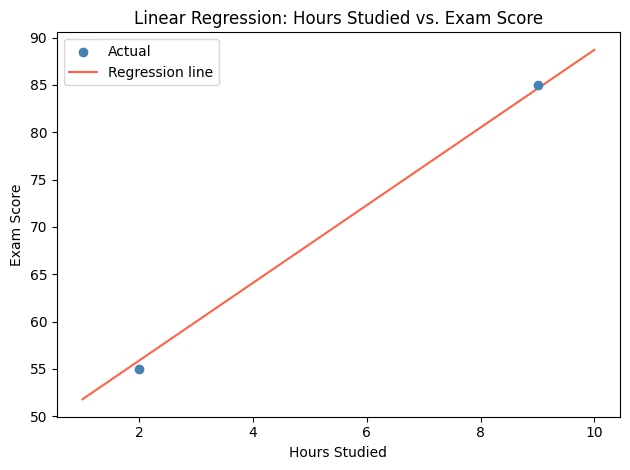

In [8]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
 X['hours_studied'].min(),
 X['hours_studied'].max(),
 100).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points are actually pretty closely following the regression line

## Lab 2
### Building your own model

In [11]:
ad_data = {
 'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
 'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [13]:
x2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(x2.shape)
print(y2.shape)

(20, 1)
(20,)


In [14]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

In [20]:
model2 = LinearRegression()
model2.fit(x2_train, y2_train)
print('Model trained successfullly.')

Model trained successfullly.


In [22]:
print(f'Slope (coefficient):  {model2.coef_[0]:.2f}')
print(f'Intercept:  {model2.intercept_:.2f}')
# For each additional $1 , the predicted monthly revenue increases by $1.96

Slope (coefficient):  1.96
Intercept:  3625.89


### Making predictions and evaluating the model

In [23]:
y2_pred = model.predict(x2_test)

print('Actual scores:    ', list(y2_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:     [4200, 21500, 19400, 5100]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [24]:
r_squared = model.score(x2_test, y2_test)
print(f'R² score: {r_squared:.2f}')

R² score: 1.00


The model does appear to be a good fit. 100% of the variation in revenue is exaplined by ad spend.

### Visualizing the results

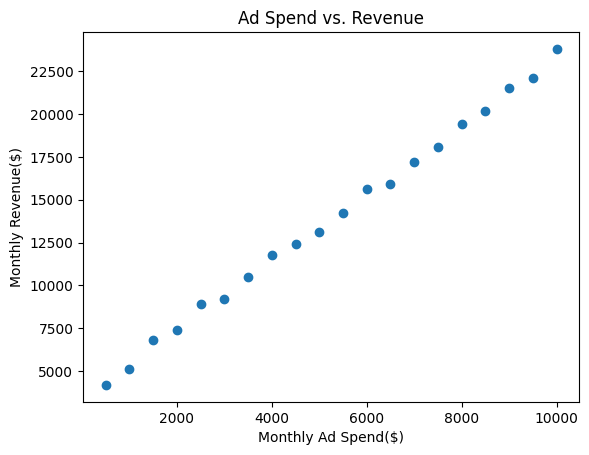

In [25]:
plt.scatter(x2,y2)
plt.xlabel('Monthly Ad Spend($)')
plt.ylabel('Monthly Revenue($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

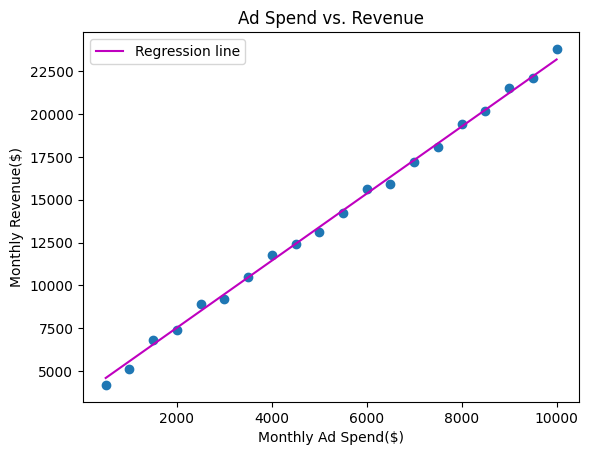

In [ ]:
plt.scatter(x2,y2)\

plt.plot(x2,model2.predict(x2), color='m', label='Regression line')

plt.xlabel('Monthly Ad Spend($)')
plt.ylabel('Monthly Revenue($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()

plt.show()

for the most part the regression line does appear to fit the data well visually but at the bottom and top the dots aren't on the line which the R2 score said otherwise it all would fit.